# Домашнее задание: Сегментация с предобученным UNet

## 1. Установка зависимостей

In [8]:
!pip install -q segmentation-models-pytorch albumentations


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


# 2. Импорты


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
import numpy as np
from PIL import Image
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.cuda.amp import autocast
import cv2

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

torch.manual_seed(42)
np.random.seed(42)
pl.seed_everything(42)

Seed set to 42


PyTorch version: 2.0.1+cu118
CUDA available: True
CUDA version: 11.8


42

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.0.1+cu118
CUDA available: True
CUDA version: 11.8


# 3. Улучшенная аугментации


In [3]:
def get_train_augmentation(img_size=(512, 512)):
    return A.Compose([
        A.Resize(img_size[0], img_size[1]),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10),
        ], p=0.5),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0)),
            A.GaussianBlur(blur_limit=(3, 5)),
        ], p=0.2),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_val_augmentation(img_size=(512, 512)):
    return A.Compose([
        A.Resize(img_size[0], img_size[1]),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

# 4. CamVidDataset


In [4]:
class CamVidDataset(Dataset):
    def __init__(self, data_dir, split='train', img_size=(512, 512), transform=None):
        self.data_dir = data_dir
        self.img_size = img_size
        self.transform = transform
        
        txt_file = os.path.join(data_dir, split + '.txt')
        self.samples = []
        
        with open(txt_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    parts = line.split()
                    if len(parts) >= 2:
                        img_path_abs = parts[0]
                        mask_path_abs = parts[1]
                        
                        img_filename = os.path.basename(img_path_abs)
                        mask_filename = os.path.basename(mask_path_abs)
                        
                        img_path = os.path.join(data_dir, split, img_filename)
                        mask_path = os.path.join(data_dir, split + 'annot', mask_filename)
                        
                        if os.path.exists(img_path) and os.path.exists(mask_path):
                            self.samples.append((img_path, mask_path))
        
        print("Loaded {} samples from {} split".format(len(self.samples), split))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
            # Преобразуем маску в Long после аугментаций
            mask = mask.long()  
        else:
            # Без аугментаций, просто resize
            image = cv2.resize(image, self.img_size, interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)
            
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()  # <-- Уже Long
        
        return image, mask

# 5. Focal Loss


In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# 6. Модель UNet с timm-efficientnet-b3


In [7]:
encoder_name = "timm-efficientnet-b3"
encoder_weights = "imagenet"

model = smp.Unet(
    encoder_name=encoder_name,
    encoder_weights=encoder_weights,
    in_channels=3,
    classes=12,
    activation=None,
    decoder_attention_type='scse',
    encoder_depth=5,
    decoder_channels=[256, 128, 64, 32, 16],
)

print(f"Model: UNet with {encoder_name} encoder")
print(f"Encoder weights: {encoder_weights}")
print(f"Number of classes: 12")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Model: UNet with timm-efficientnet-b3 encoder
Encoder weights: imagenet
Number of classes: 12
Number of parameters: 13,224,290


# 7. Lightning Module


In [8]:
class UNetModule(pl.LightningModule):
    def __init__(self, model, learning_rate=3e-4, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        
        self.model = model
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.n_classes = 12
        
        self.focal_loss = FocalLoss(alpha=0.8, gamma=2.0)
        self.dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.ce_loss = nn.CrossEntropyLoss()
        
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        images, masks = batch
        
        if masks.dtype != torch.long:
            masks = masks.long()
        
        with autocast(enabled=True):
            logits = self.forward(images)
            
            # Комбинированная loss
            focal = self.focal_loss(logits, masks)
            dice = self.dice_loss(logits, masks)
            loss = 0.4 * focal + 0.4 * dice + 0.2 * self.ce_loss(logits, masks)
            
            preds = torch.argmax(logits, dim=1)
            iou = self.compute_iou(preds, masks)
        
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_iou', iou, on_step=True, on_epoch=True, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        images, masks = batch
        
        if masks.dtype != torch.long:
            masks = masks.long()
        
        with autocast(enabled=True):
            logits = self.forward(images)
            
            focal = self.focal_loss(logits, masks)
            dice = self.dice_loss(logits, masks)
            loss = 0.4 * focal + 0.4 * dice + 0.2 * self.ce_loss(logits, masks)
            
            preds = torch.argmax(logits, dim=1)
            iou = self.compute_iou(preds, masks)
        
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_iou', iou, on_step=False, on_epoch=True, prog_bar=True)
        
        return loss
    
    def test_step(self, batch, batch_idx):
        images, masks = batch
        
        if masks.dtype != torch.long:
            masks = masks.long()
        
        with autocast(enabled=True):
            logits = self.forward(images)
            
            focal = self.focal_loss(logits, masks)
            dice = self.dice_loss(logits, masks)
            loss = 0.4 * focal + 0.4 * dice + 0.2 * self.ce_loss(logits, masks)
            
            preds = torch.argmax(logits, dim=1)
            iou = self.compute_iou(preds, masks)
        
        self.log('test_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('test_iou', iou, on_step=False, on_epoch=True, prog_bar=True)
        
        return loss
    
    def compute_iou(self, preds, targets):
        ious = []
        for cls in range(self.n_classes):
            pred_cls = (preds == cls)
            target_cls = (targets == cls)
            intersection = (pred_cls & target_cls).float().sum((1, 2))
            union = (pred_cls | target_cls).float().sum((1, 2))
            iou = (intersection + 1e-6) / (union + 1e-6)
            ious.append(iou.mean())
        return torch.stack(ious).mean()
    
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), 
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.learning_rate,
            total_steps=self.trainer.estimated_stepping_batches,
            pct_start=0.3,
            anneal_strategy='cos',
            div_factor=25.0,
            final_div_factor=10000.0
        )
        
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'step',
                'frequency': 1
            }
        }

# 8. Загрузка данных


In [9]:
data_dir = './data'

train_transform = get_train_augmentation(img_size=(512, 512))
val_transform = get_val_augmentation(img_size=(512, 512))

train_dataset = CamVidDataset(
    data_dir=data_dir,
    split='train',
    img_size=(512, 512),
    transform=train_transform
)

val_dataset = CamVidDataset(
    data_dir=data_dir,
    split='val',
    img_size=(512, 512),
    transform=val_transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

batch_size = 16
num_workers = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)

Loaded 367 samples from train split
Loaded 101 samples from val split
Train samples: 367
Val samples: 101


# 9. Визуализация данных


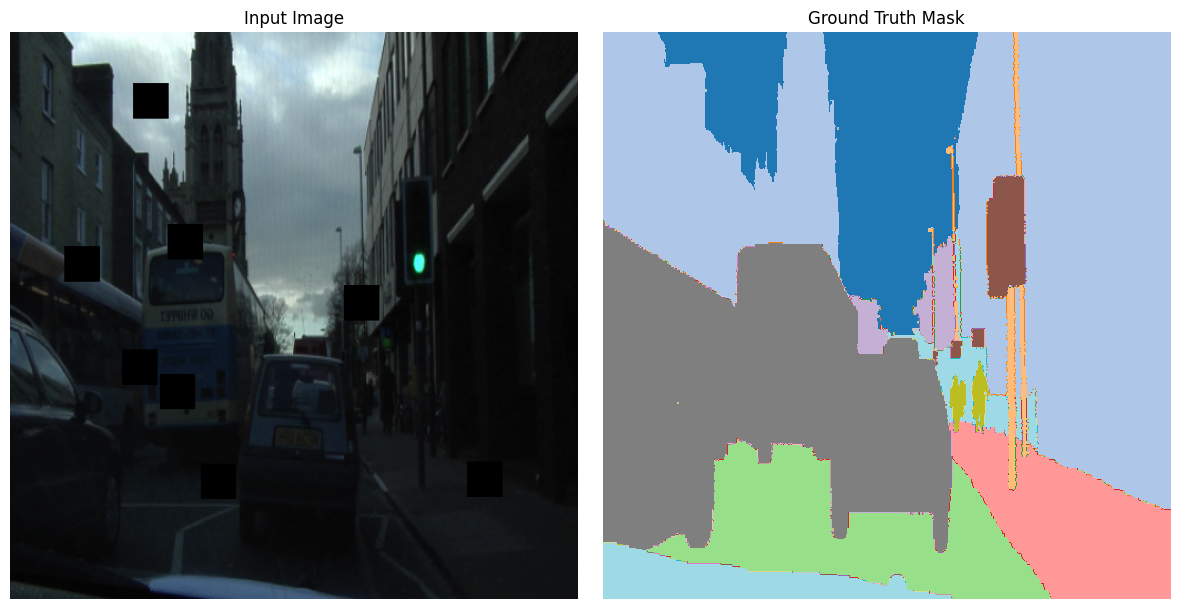

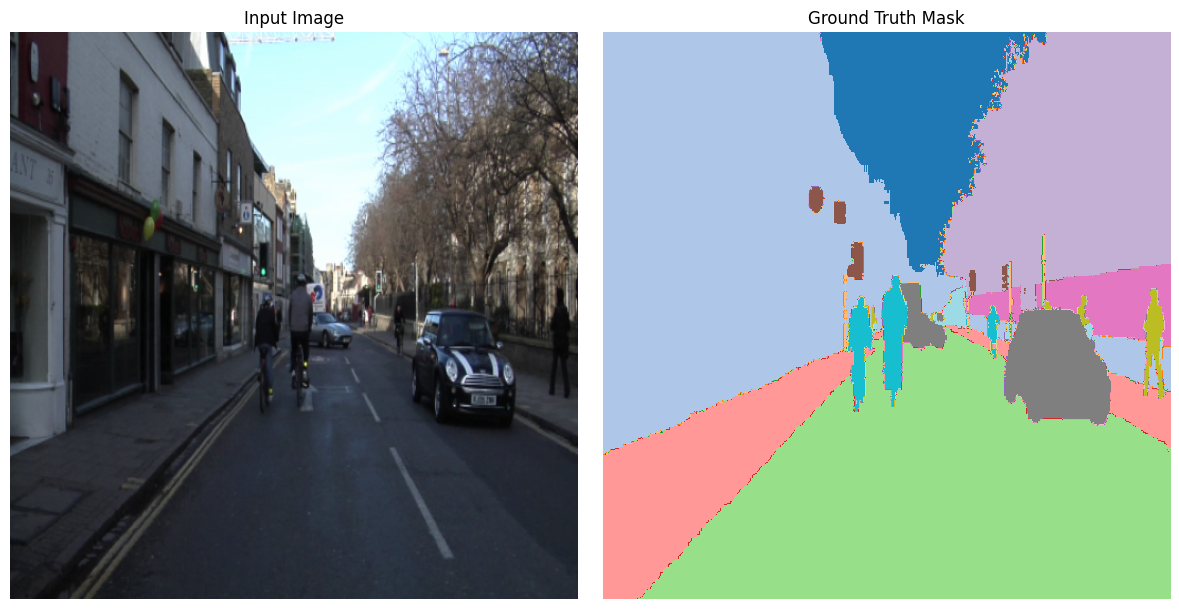

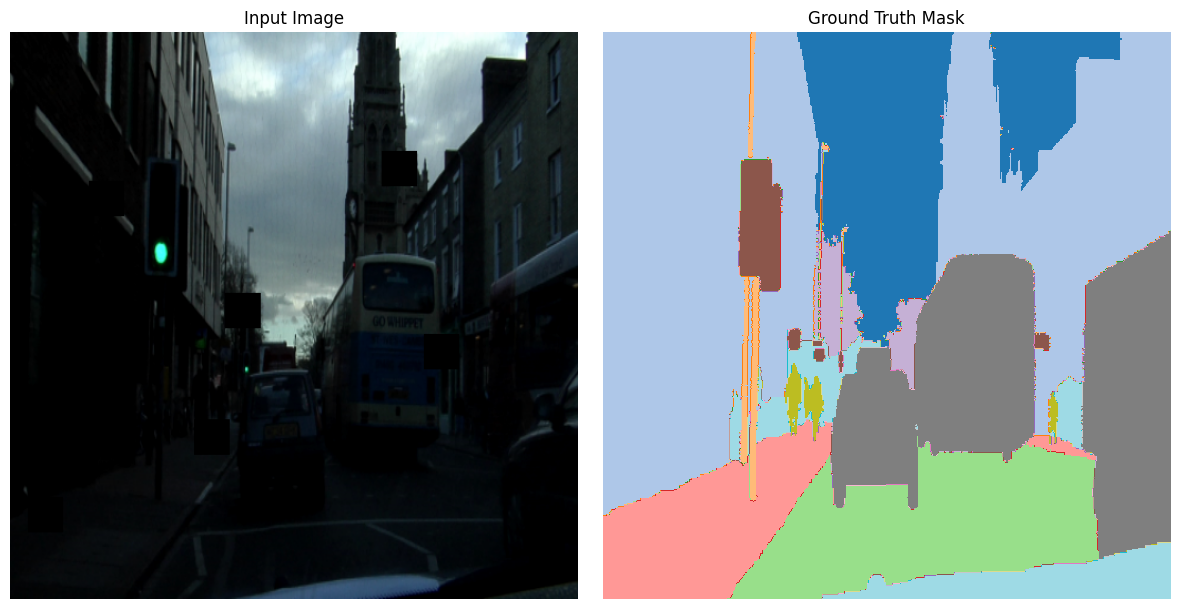

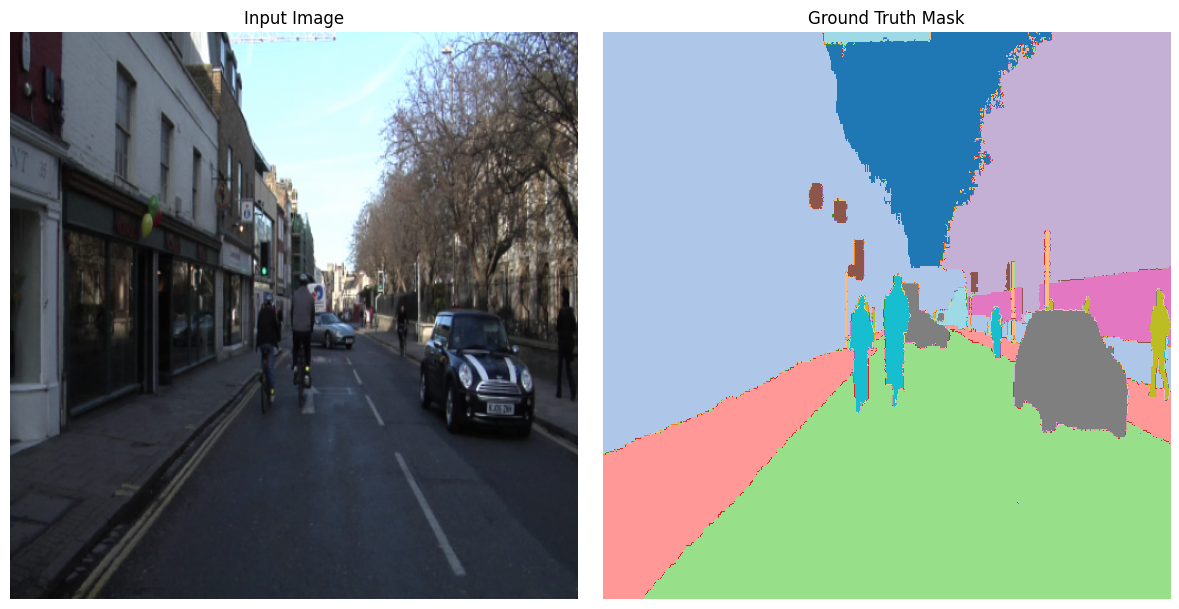

In [10]:
def visualize_sample(dataset, idx=0):
    image, mask = dataset[idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Денормализация изображения
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = image.permute(1, 2, 0).cpu().numpy()
    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)
    
    axes[0].imshow(image_np)
    axes[0].set_title('Input Image')
    axes[0].axis('off')
    
    axes[1].imshow(mask.cpu().numpy(), cmap='tab20', vmin=0, vmax=11)
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Визуализируем несколько примеров
for i in range(2):
    visualize_sample(train_dataset, i)
    visualize_sample(val_dataset, i)

# 10. Настройка обучения


In [11]:
# Создаем Lightning модуль
model_module = UNetModule(model, learning_rate=3e-4, weight_decay=1e-4)

# Callbacks
checkpoint_callback = ModelCheckpoint(
    monitor='val_iou',
    mode='max',
    save_top_k=3,
    save_last=True,
    filename='unet-{epoch:02d}-{val_iou:.3f}',
    dirpath='./checkpoints',
    verbose=True
)

early_stop_callback = EarlyStopping(
    monitor='val_iou',
    patience=25,
    mode='max',
    min_delta=0.001,
    verbose=True
)

lr_monitor = LearningRateMonitor(logging_interval='step')

# Logger
logger = TensorBoardLogger('tb_logs', name='unet_resnet50_camvid', version='v1')

# Trainer
trainer = pl.Trainer(
    max_epochs=100,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    logger=logger,
    callbacks=[checkpoint_callback, early_stop_callback, lr_monitor],
    precision=16,
    accumulate_grad_batches=2,
    gradient_clip_val=1.0,
    deterministic=False,
    log_every_n_steps=20,
    check_val_every_n_epoch=1,
    enable_progress_bar=True,
)

/home/jupyter/.local/lib/python3.10/site-packages/lightning_fabric/connector.py:563: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


# 11. Обучение модели


In [12]:
# Обучение
trainer.fit(model_module, train_loader, val_loader)

2025-12-06 15:55:20.293416: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-06 15:55:21.605297: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jupyter/.local/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:652: Checkpoint directory /home/jupyter/project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name       | Type             | Params
------------------------------------------------
0 | model      | Unet             | 13.2 M
1 | focal_loss | FocalLoss        | 0     
2 | dice_loss  | DiceLoss         | 0     
3 | ce_loss    | CrossEntropyLoss | 0     
-------

Epoch 0: 100%|██████████| 22/22 [00:07<00:00,  2.79it/s, v_num=v1, train_loss_step=1.840, train_iou_step=0.00953]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 22/22 [00:10<00:00,  2.11it/s, v_num=v1, train_loss_step=1.840, train_iou_step=0.00953, val_loss=1.820, val_iou=0.00768, train_loss_epoch=1.860, train_iou_epoch=0.00995]

Metric val_iou improved. New best score: 0.008
Epoch 0, global step 11: 'val_iou' reached 0.00768 (best 0.00768), saving model to '/home/jupyter/project/checkpoints/unet-epoch=00-val_iou=0.008.ckpt' as top 3


Epoch 1: 100%|██████████| 22/22 [00:08<00:00,  2.50it/s, v_num=v1, train_loss_step=1.790, train_iou_step=0.0123, val_loss=1.820, val_iou=0.00768, train_loss_epoch=1.860, train_iou_epoch=0.00995] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 22/22 [00:10<00:00,  2.06it/s, v_num=v1, train_loss_step=1.790, train_iou_step=0.0123, val_loss=1.940, val_iou=0.00908, train_loss_epoch=1.820, train_iou_epoch=0.011]  

Metric val_iou improved by 0.001 >= min_delta = 0.001. New best score: 0.009
Epoch 1, global step 22: 'val_iou' reached 0.00908 (best 0.00908), saving model to '/home/jupyter/project/checkpoints/unet-epoch=01-val_iou=0.009.ckpt' as top 3


...

Epoch 98: 100%|██████████| 22/22 [00:08<00:00,  2.64it/s, v_num=v1, train_loss_step=0.170, train_iou_step=0.668, val_loss=0.242, val_iou=0.660, train_loss_epoch=0.176, train_iou_epoch=0.655]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 98: 100%|██████████| 22/22 [00:10<00:00,  2.17it/s, v_num=v1, train_loss_step=0.170, train_iou_step=0.668, val_loss=0.241, val_iou=0.661, train_loss_epoch=0.174, train_iou_epoch=0.658]

Epoch 98, global step 1089: 'val_iou' reached 0.66097 (best 0.66111), saving model to '/home/jupyter/project/checkpoints/unet-epoch=98-val_iou=0.661.ckpt' as top 3


Epoch 99: 100%|██████████| 22/22 [00:08<00:00,  2.50it/s, v_num=v1, train_loss_step=0.189, train_iou_step=0.661, val_loss=0.241, val_iou=0.661, train_loss_epoch=0.174, train_iou_epoch=0.658]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 99: 100%|██████████| 22/22 [00:10<00:00,  2.10it/s, v_num=v1, train_loss_step=0.189, train_iou_step=0.661, val_loss=0.244, val_iou=0.661, train_loss_epoch=0.173, train_iou_epoch=0.659]

Epoch 99, global step 1100: 'val_iou' was not in top 3
`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 22/22 [00:13<00:00,  1.68it/s, v_num=v1, train_loss_step=0.189, train_iou_step=0.661, val_loss=0.244, val_iou=0.661, train_loss_epoch=0.173, train_iou_epoch=0.659]


# 12: Загрузка лучшей модели


In [13]:
# Загружаем лучшую модель
best_model_path = checkpoint_callback.best_model_path
print(f"Best model path: {best_model_path}")
print(f"Best model score (val_iou): {checkpoint_callback.best_model_score:.1f}")

Best model path: /home/jupyter/project/checkpoints/unet-epoch=94-val_iou=0.661.ckpt
Best model score (val_iou): 0.7
